# Per-Gene Population Evaluation

How well is each gene reconstructed across GTEx samples?

1. **Section 1** — overall: ranked curve + histogram across all samples, one line per model.
2. **Section 2** — tissue-stratified: ranked curve + histogram with one line per tissue (single model) and a per-tissue × per-model heat in the table.

The gene panel is set in **one place** (`GENE_LIST_PATH` mini-config) and threaded through both sections, so swapping the panel only requires editing that one cell + re-running the compute cell.


## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Section 1 — Overall (all GTEx samples)
- Section 2 — Tissue-stratified
- Section 3 — Gene-sublist scatter (3 models)
- Section 4 — Interactive single-gene scatter


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as _np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *

## Notebook Configuration

Global / cross-section knobs in the next cell. Per-section knobs live in mini-config cells immediately above their use sites.


In [3]:
# === Global config ===
set_academic_style()

# Switch this one value when comparing cache families.
#   c        = centroid matching, covariate-aware ComBat
#   cv       = centroid+volume matching, covariate-aware ComBat
#   cv_nocov = centroid+volume matching, no ComBat covariates
CACHE_VARIANT = 'cv'  # 'c' | 'cv' | 'cv_nocov'
CACHE_VARIANTS = {
    'c': dict(
        cache_root='out/loro_subject_cache_c',
        combat_use_covariates=True,
        matching_policy='centroids',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv': dict(
        cache_root='out/loro_subject_cache_cv_rbf_shrink',
        combat_use_covariates=True,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
    'cv_nocov': dict(
        cache_root='out/loro_subject_cache_cv_nocov',
        combat_use_covariates=False,
        matching_policy='centroids_and_volumes',
        matching_policy_hemi_mode='force_left',
        collapse_cerebellum=False,
    ),
}
CACHE_CFG = CACHE_VARIANTS[CACHE_VARIANT]

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root=CACHE_CFG['cache_root'],
    gene_scope='allgenes',
    combat_use_covariates=CACHE_CFG['combat_use_covariates'],
    matching_policy=CACHE_CFG['matching_policy'],
    matching_policy_hemi_mode=CACHE_CFG['matching_policy_hemi_mode'],
    collapse_cerebellum=CACHE_CFG['collapse_cerebellum'],
    gtex_rep_mode='centroid',
    gtex_hemi_mode='mirror_left',
)
print('cache variant:', CACHE_VARIANT)
print('cache root:', CFG.cache_root)
print('analysis scope:', CFG.gene_scope)
print('combat_use_covariates:', CFG.combat_use_covariates)
print('matching:', CFG.matching_policy, CFG.matching_policy_hemi_mode, 'collapse_cerebellum=', CFG.collapse_cerebellum)

MODELS                       = ['naive', 'dlam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = True

VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse


cache variant: cv
cache root: out/loro_subject_cache_cv_rbf_shrink
analysis scope: allgenes
combat_use_covariates: True
matching: centroids_and_volumes force_left collapse_cerebellum= False


## Shared Reconstruction

`PREPOST` + canonical wide truth/pred tables. The view used for the per-gene scoring is constructed in **Section 1** below using `GENE_LIST_PATH` so swapping panels is a single-cell edit.


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])

[prepost_cache] hit  notebooks/cache/prepost/50af9df33738c5d3.pkl  (8961.2 MB)
subjects: 318
genes: 11704
parcels: 150


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)
print({model: df.shape for model, df in pred_dfs.items()})

{'naive': (2869, 11722), 'dlam': (2869, 11722)}


In [6]:
# Helper: build a gene-panel-scoped view from globals (truth_df / pred_dfs / VIEW_SUBSET).
# Keeps each section's setup to a single line.
def build_panel_view(gene_list_path=None, models=None, **overrides):
    subset = {**VIEW_SUBSET, **overrides}
    return make_prediction_eval_view(
        truth_df=truth_df, pred_dfs=pred_dfs,
        eval_gene_list_path=gene_list_path,
        models=list(models) if models is not None else MODELS,
        **subset,
    )


## Section 1 — Overall (all GTEx samples)

One ranked curve and one histogram across **all GTEx samples**, with one line per model. The gene panel is set once at the top of this section and reused by Section 2.


In [7]:
# Section 1 config — gene panel + compute knobs (shared with Section 2)
GENE_LIST_PATH       = None # 'gtex_100hvg'                # None = all genes; e.g. 'gtex_100hvg', 'syngo', 'richiardi2015', or a path
GENEWISE_METRICS     = ['pearson_r', 'r2', 'rmse']
GENEWISE_N_JOBS      = N_JOBS

# Plot knobs (overall view)
GENEWISE_RANKED_METRIC          = DEFAULT_METRIC
GENEWISE_RANKED_ANCHOR_MODEL    = 'dlam'
GENEWISE_RANKED_LABEL_STEP_PCT  = 10.0    # label one anchor-model gene per 10%; None = no top labels
GENEWISE_LABELED_GENES          = None    # explicit callouts, e.g. ['PVALB', 'GFAP', 'SLC17A7']
GENEWISE_HIST_BINS              = 60
GENEWISE_HIST_ALPHA             = 0.42


In [8]:
# Build the gene-panel-scoped view + compute genewise metrics across ALL samples (no stratification).
genewise_view = build_panel_view(GENE_LIST_PATH)
print('view genes:', len(genewise_view['genes']))

genewise_df = compute_genewise_metrics(
    genewise_view,
    models=MODELS,
    metrics=GENEWISE_METRICS,
    n_jobs=GENEWISE_N_JOBS,
)
print('genewise_df:', genewise_df.shape)
display(
    genewise_df.groupby('model', as_index=False).agg(
        n_genes=('gene', 'nunique'),
        n_samples=('n_samples', 'first'),
        median_pearson=('pearson_r', 'median'),
        median_r2=('r2', 'median'),
        median_rmse=('rmse', 'median'),
    )
)


view genes: 11704
genewise_df: (23408, 11)


,model,n_genes,n_samples,median_pearson,median_r2,median_rmse
0,dlam,11704,2869,-0.013951,-147917.522691,72.499533
1,naive,11704,2869,0.221618,-1.138180,0.395048


### Ranked curve

Genes are sorted worst → best within each model and plotted by rank percentile. Anchor-model gene names sit on the curve at every `GENEWISE_RANKED_LABEL_STEP_PCT`-th percentile; pass `GENEWISE_LABELED_GENES=[...]` to add explicit callouts.


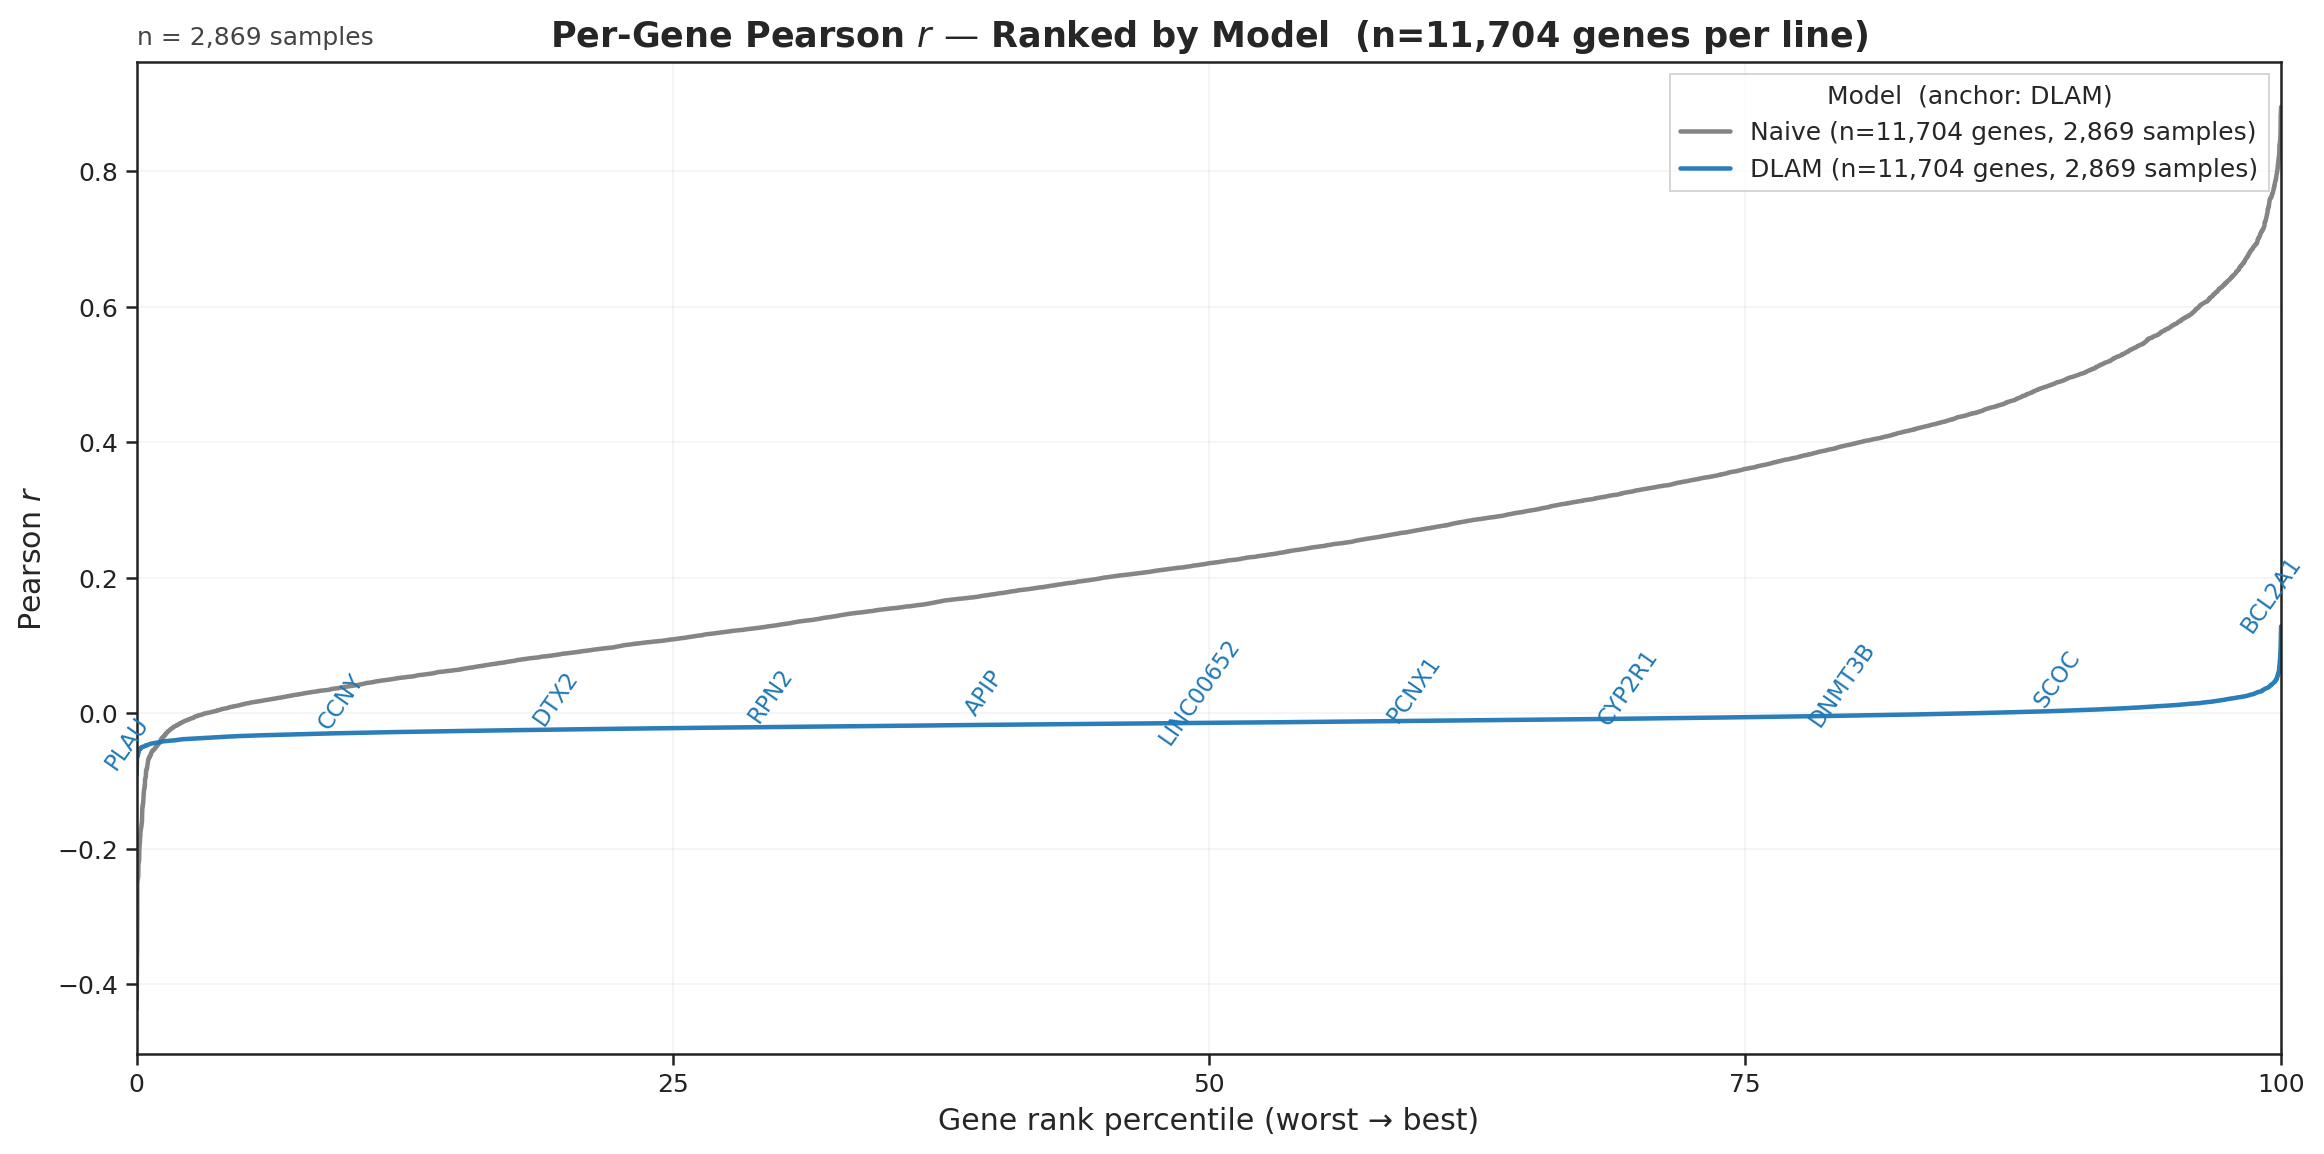

In [9]:
fig, ax, ranked_genewise = plot_genewise_ranked_overlay(
    genewise_df,
    metric=GENEWISE_RANKED_METRIC,
    group_by='model',
    groups=MODELS,
    anchor=GENEWISE_RANKED_ANCHOR_MODEL,
    gene_label_step_pct=GENEWISE_RANKED_LABEL_STEP_PCT,
    labeled_genes=GENEWISE_LABELED_GENES,
)

rb### Histogram

Overlapping per-model distributions of the per-gene metric, with each model's median as a dashed rule.


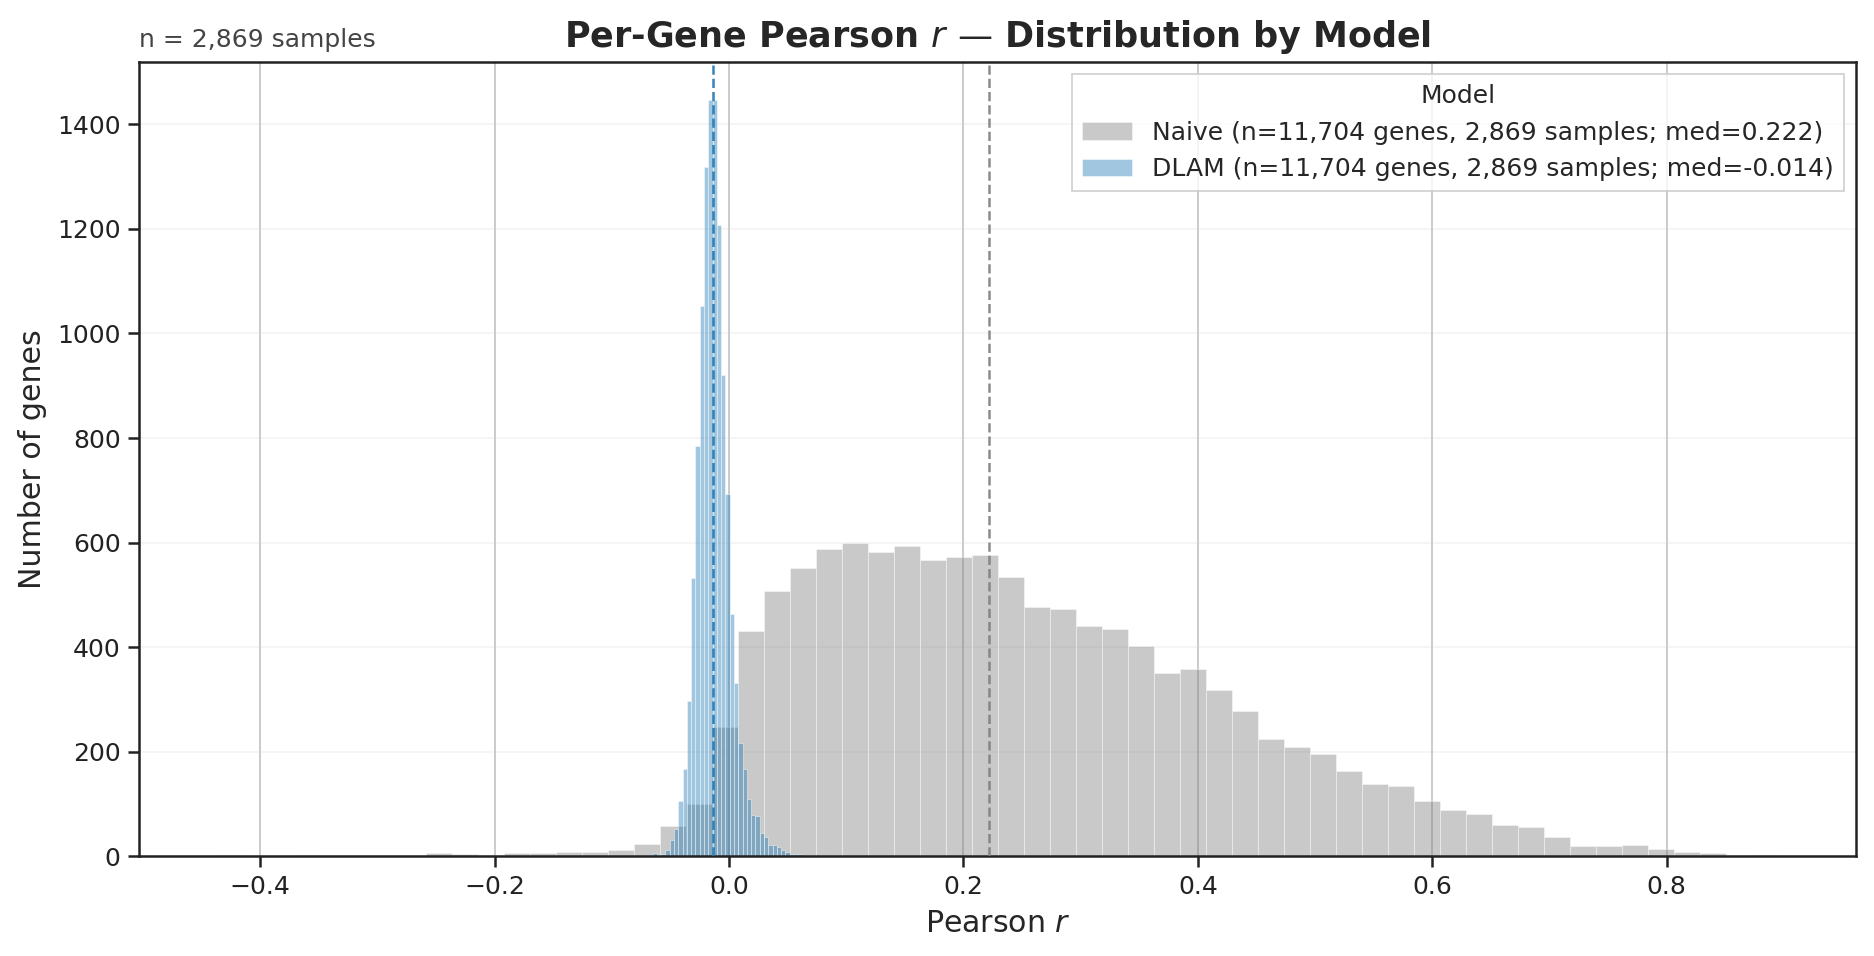

In [10]:
fig, ax = plot_genewise_histogram(
    genewise_df,
    metric=GENEWISE_RANKED_METRIC,
    group_by='model',
    groups=MODELS,
    bins=GENEWISE_HIST_BINS,
    alpha=GENEWISE_HIST_ALPHA,
    show_median=True,
)

In [11]:
print(global_manifest["source_cache_root"])
print(global_manifest["cache_dir"])
print(global_manifest["created_at_utc"])

out/loro_subject_cache_cv_rbf_shrink
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/out/eval_prediction_tables/loro_subject_cache_cv_rbf_shrink/allgenes
2026-05-27T19:58:25.630294+00:00


## Section 2 — Tissue-stratified

Recompute genewise metrics filtered per GTEx tissue (one row per `(model, gtex_region, gene)`; `n_samples` is per-tissue). Two views:

1. **Single model, ranked by tissue** — one line per tissue using the shared region palette.
2. **Single model, distribution by tissue** — overlapping histograms across tissues.

To inspect a different model swap `TISSUE_VIEW_MODEL`; to restrict to a subset of tissues, set `TISSUE_VIEW_GROUPS` (e.g. `['Brain - Cortex', 'Brain - Cerebellum']`).


In [12]:
# Section 2 config
TISSUE_VIEW_MODEL          = 'dlam'   # which model's lines to draw
TISSUE_VIEW_GROUPS         = None     # None = all tissues; or list of gtex_region strings
TISSUE_VIEW_LABEL_STEP_PCT = 10.0     # gene labels every 20%; tissues have far fewer genes than the full panel
TISSUE_VIEW_LABELED_GENES  = None

In [13]:
genewise_tissue_df = compute_genewise_metrics(
    genewise_view,
    models=MODELS,
    metrics=GENEWISE_METRICS,
    stratify_by='gtex_region',
    n_jobs=GENEWISE_N_JOBS,
)
print('genewise_tissue_df:', genewise_tissue_df.shape)
display(
    genewise_tissue_df.groupby(['model', 'gtex_region'], as_index=False).agg(
        n_genes=('gene', 'nunique'),
        n_samples=('n_samples', 'first'),
        median=('pearson_r', 'median'),
    ).head(20)
)

genewise_tissue_df: (280896, 13)


,model,gtex_region,n_genes,n_samples,median
0,dlam,brain - amygdala,11704,181,0.009953
1,dlam,brain - anterior cingulate cortex (ba24),11704,223,0.001901
2,dlam,brain - caudate (basal ganglia),11704,279,0.163480
3,dlam,brain - cerebellar hemisphere,11704,262,-0.015636
4,dlam,brain - cerebellum,11704,251,-0.033897
5,dlam,brain - cortex,11704,240,0.015784
6,dlam,brain - frontal cortex (ba9),11704,252,0.036208
7,dlam,brain - hippocampus,11704,240,0.068508
8,dlam,brain - hypothalamus,11704,242,-0.070435
9,dlam,brain - nucleus accumbens (basal ganglia),11704,273,0.068730


### Tissue ranked curve (single model)


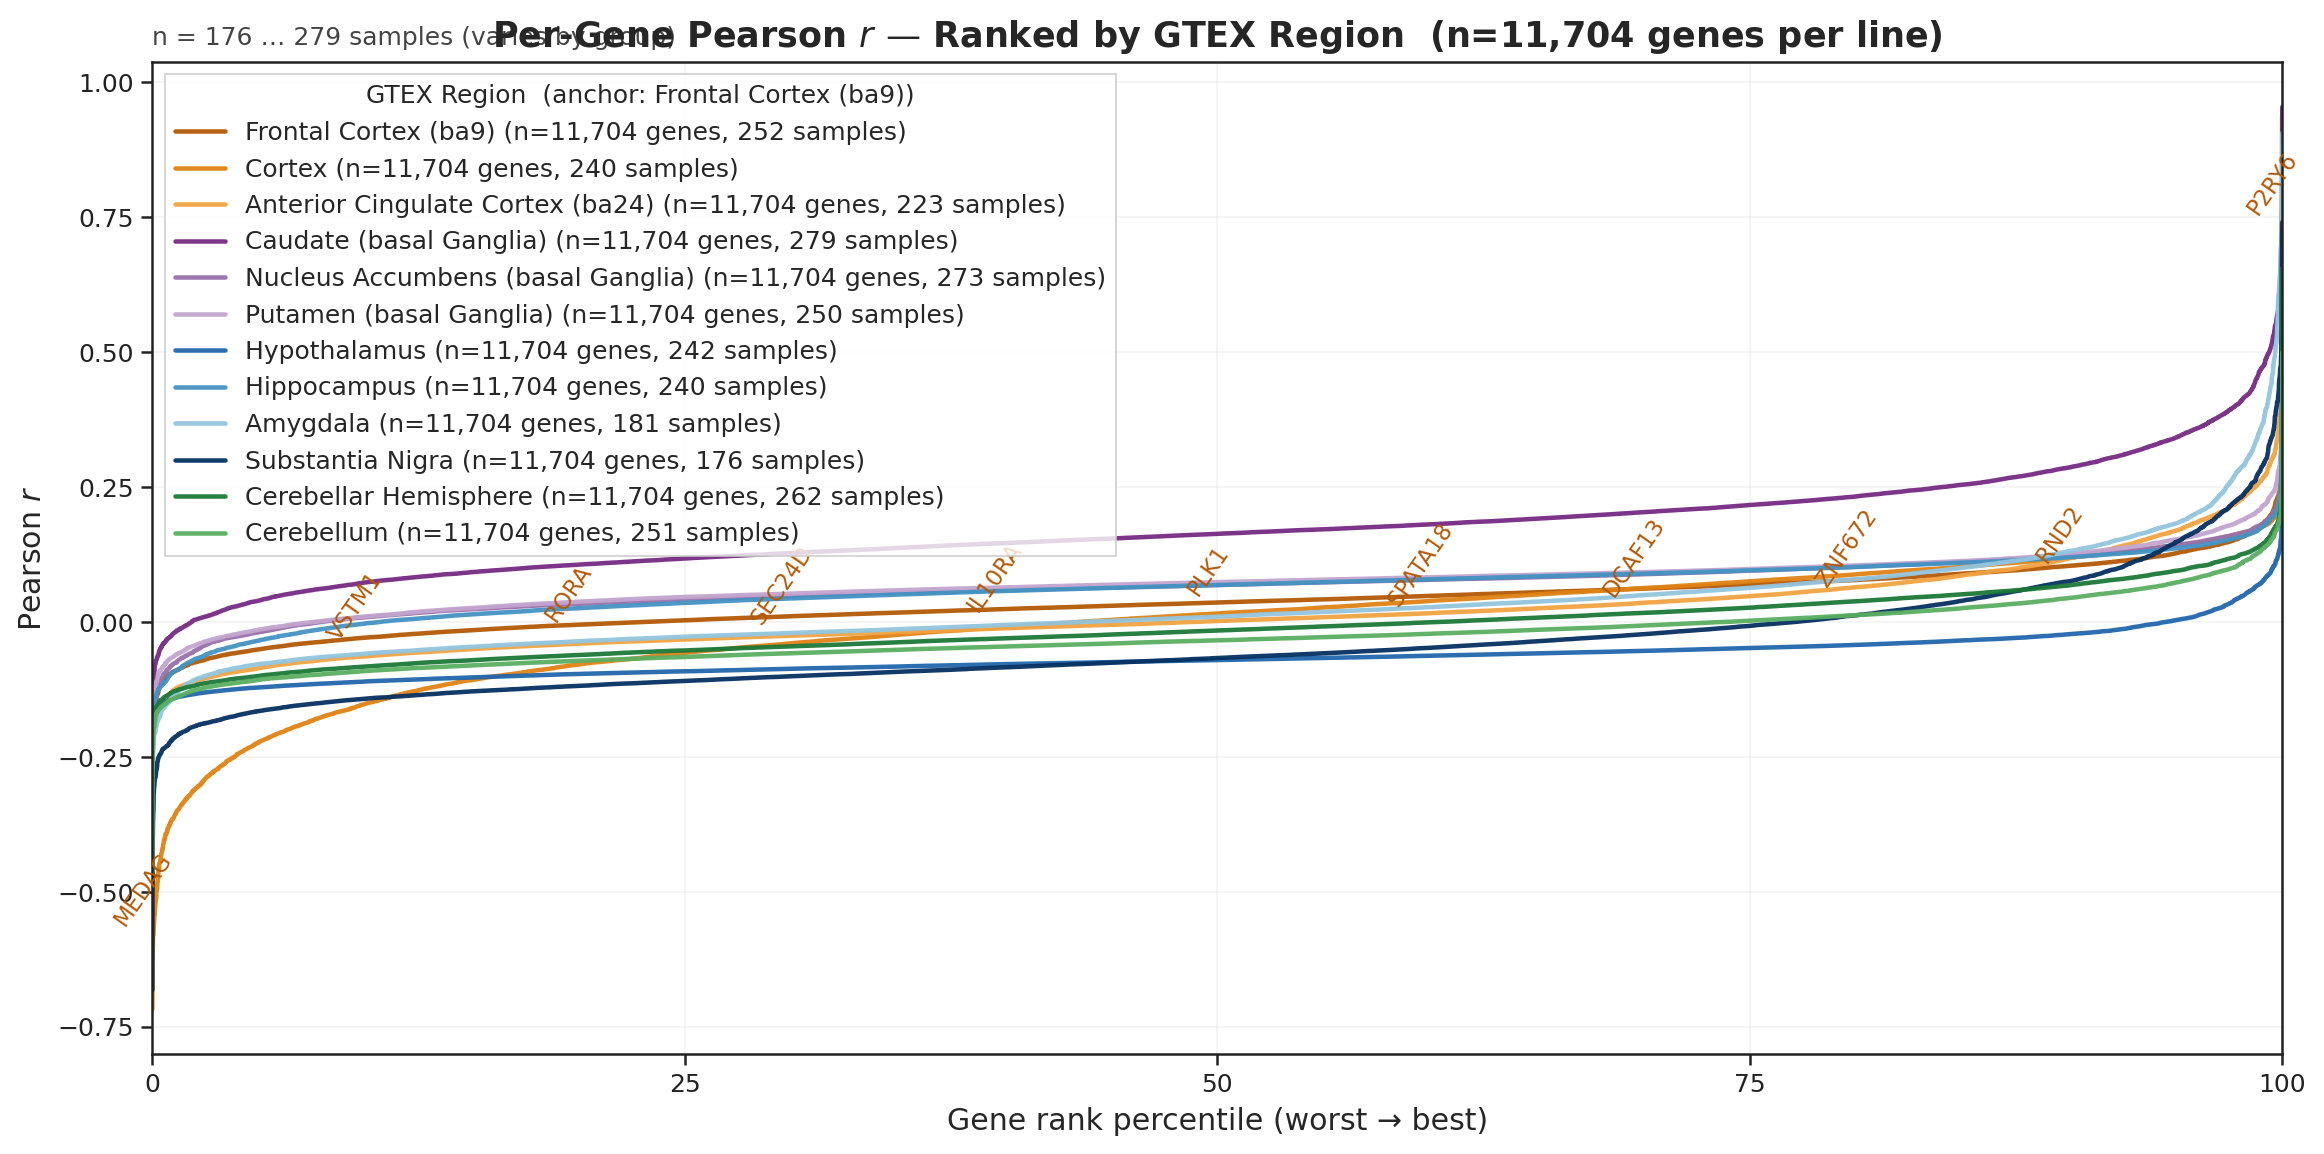

In [14]:
tissue_df_one_model = genewise_tissue_df[
    genewise_tissue_df['model'].astype(str).str.lower() == str(TISSUE_VIEW_MODEL).lower()
]

fig, ax, ranked_tissue = plot_genewise_ranked_overlay(
    tissue_df_one_model,
    metric=GENEWISE_RANKED_METRIC,
    group_by='gtex_region',
    groups=TISSUE_VIEW_GROUPS,
    gene_label_step_pct=TISSUE_VIEW_LABEL_STEP_PCT,
    labeled_genes=TISSUE_VIEW_LABELED_GENES,
)

### Tissue histogram (single model)


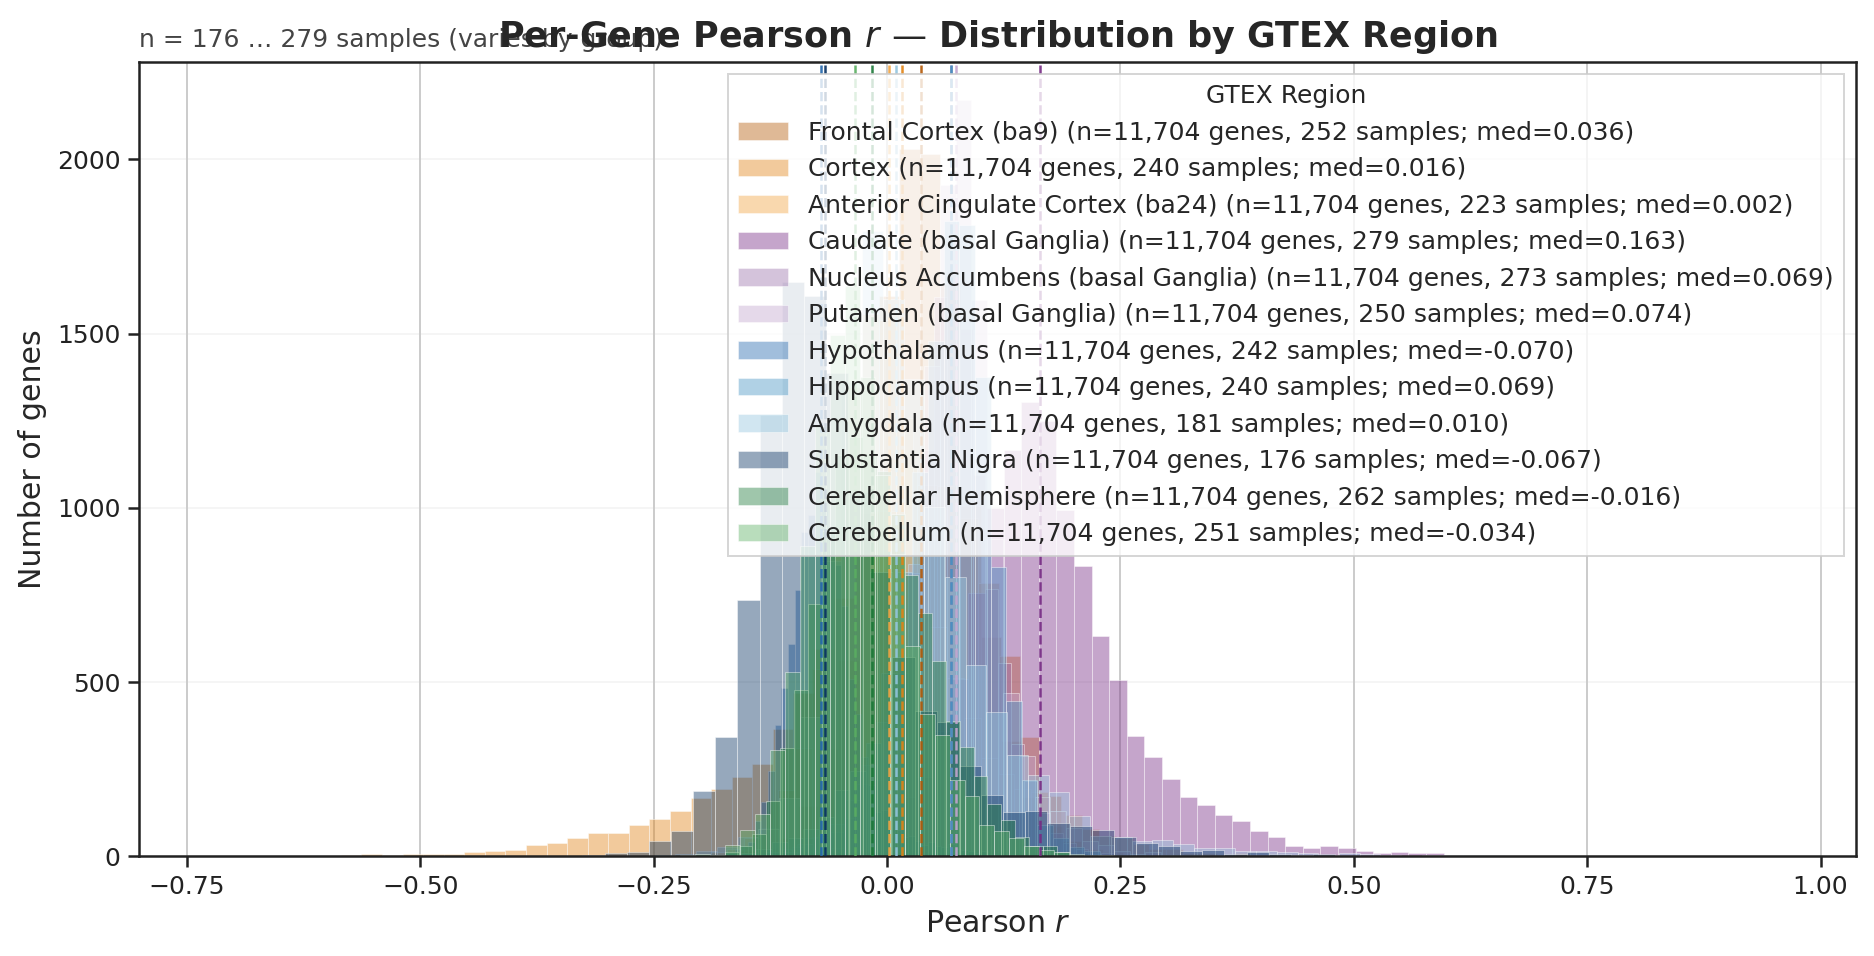

In [15]:
fig, ax = plot_genewise_histogram(
    tissue_df_one_model,
    metric=GENEWISE_RANKED_METRIC,
    group_by='gtex_region',
    groups=TISSUE_VIEW_GROUPS,
    bins=GENEWISE_HIST_BINS,
    alpha=GENEWISE_HIST_ALPHA,
    show_median=True,
)

## Section 3 — Gene-sublist scatter (3 models)

Truth-vs-prediction scatter restricted to a gene-list panel (default: `gtex_100hvg`), one figure per model. Top-N genes get distinct colors with their per-gene `pearson_r` in the legend; the rest fall into transparent gray.

Selection knobs:
- `SUBLIST_SELECTION = 'top' | 'bottom' | 'random' | 'list_order'` — which N genes get colored.
- `SUBLIST_RANK_MODEL` — which model's ranking drives the selection (so the **same** genes color across all 3 panels for direct comparison).
- `SUBLIST_HIGHLIGHT_GENES = ['PVALB','SST','SIX3']` — hard override, picks those exact genes regardless of selection mode.


In [16]:
# Section 3 config — gene-sublist scatter
SUBLIST_GENE_LIST_PATH   = 'richiardi2015'   # path/basename of the gene-panel restriction
SUBLIST_TOP_N            = 10              # number of genes to color in the legend
SUBLIST_SELECTION        = 'random'           # 'top' | 'bottom' | 'random' | 'list_order'
SUBLIST_RANK_MODEL       = 'dlam'          # which model's ranking decides the colored set
SUBLIST_RANK_METRIC      = 'pearson_r'     # ranking metric (pearson_r | spearman_r | r2 | rmse)
SUBLIST_HIGHLIGHT_GENES  = None            # e.g. ['PVALB','SST','SIX3'] — overrides selection
SUBLIST_FIGSIZE          = (7.5, 6.5)
SUBLIST_ANNOTATE_METRIC  = 'pearson_r'     # per-gene metric in legend; None = off
SUBLIST_RANDOM_SEED      = 0
SCATTER_MAX_POINTS_PER_MODEL = None        # None = no sub-sampling for the scatter draw


In [17]:
sublist_view = build_panel_view(SUBLIST_GENE_LIST_PATH)
print('sublist view genes:', len(sublist_view['genes']))

# Precompute the per-gene rank lookup ONCE against SUBLIST_RANK_MODEL on the full
# 3-model view, so the same colored gene set is reused across all three single-model
# panels (regardless of which model is in each panel's view).
if SUBLIST_SELECTION in ('top', 'bottom') and not SUBLIST_HIGHLIGHT_GENES:
    sublist_rank_lookup = compute_gene_rank_lookup(
        sublist_view, model=SUBLIST_RANK_MODEL, metric=SUBLIST_RANK_METRIC,
    )
    print(f'rank lookup: {len(sublist_rank_lookup)} genes scored against {SUBLIST_RANK_MODEL}')
else:
    sublist_rank_lookup = None


sublist view genes: 97


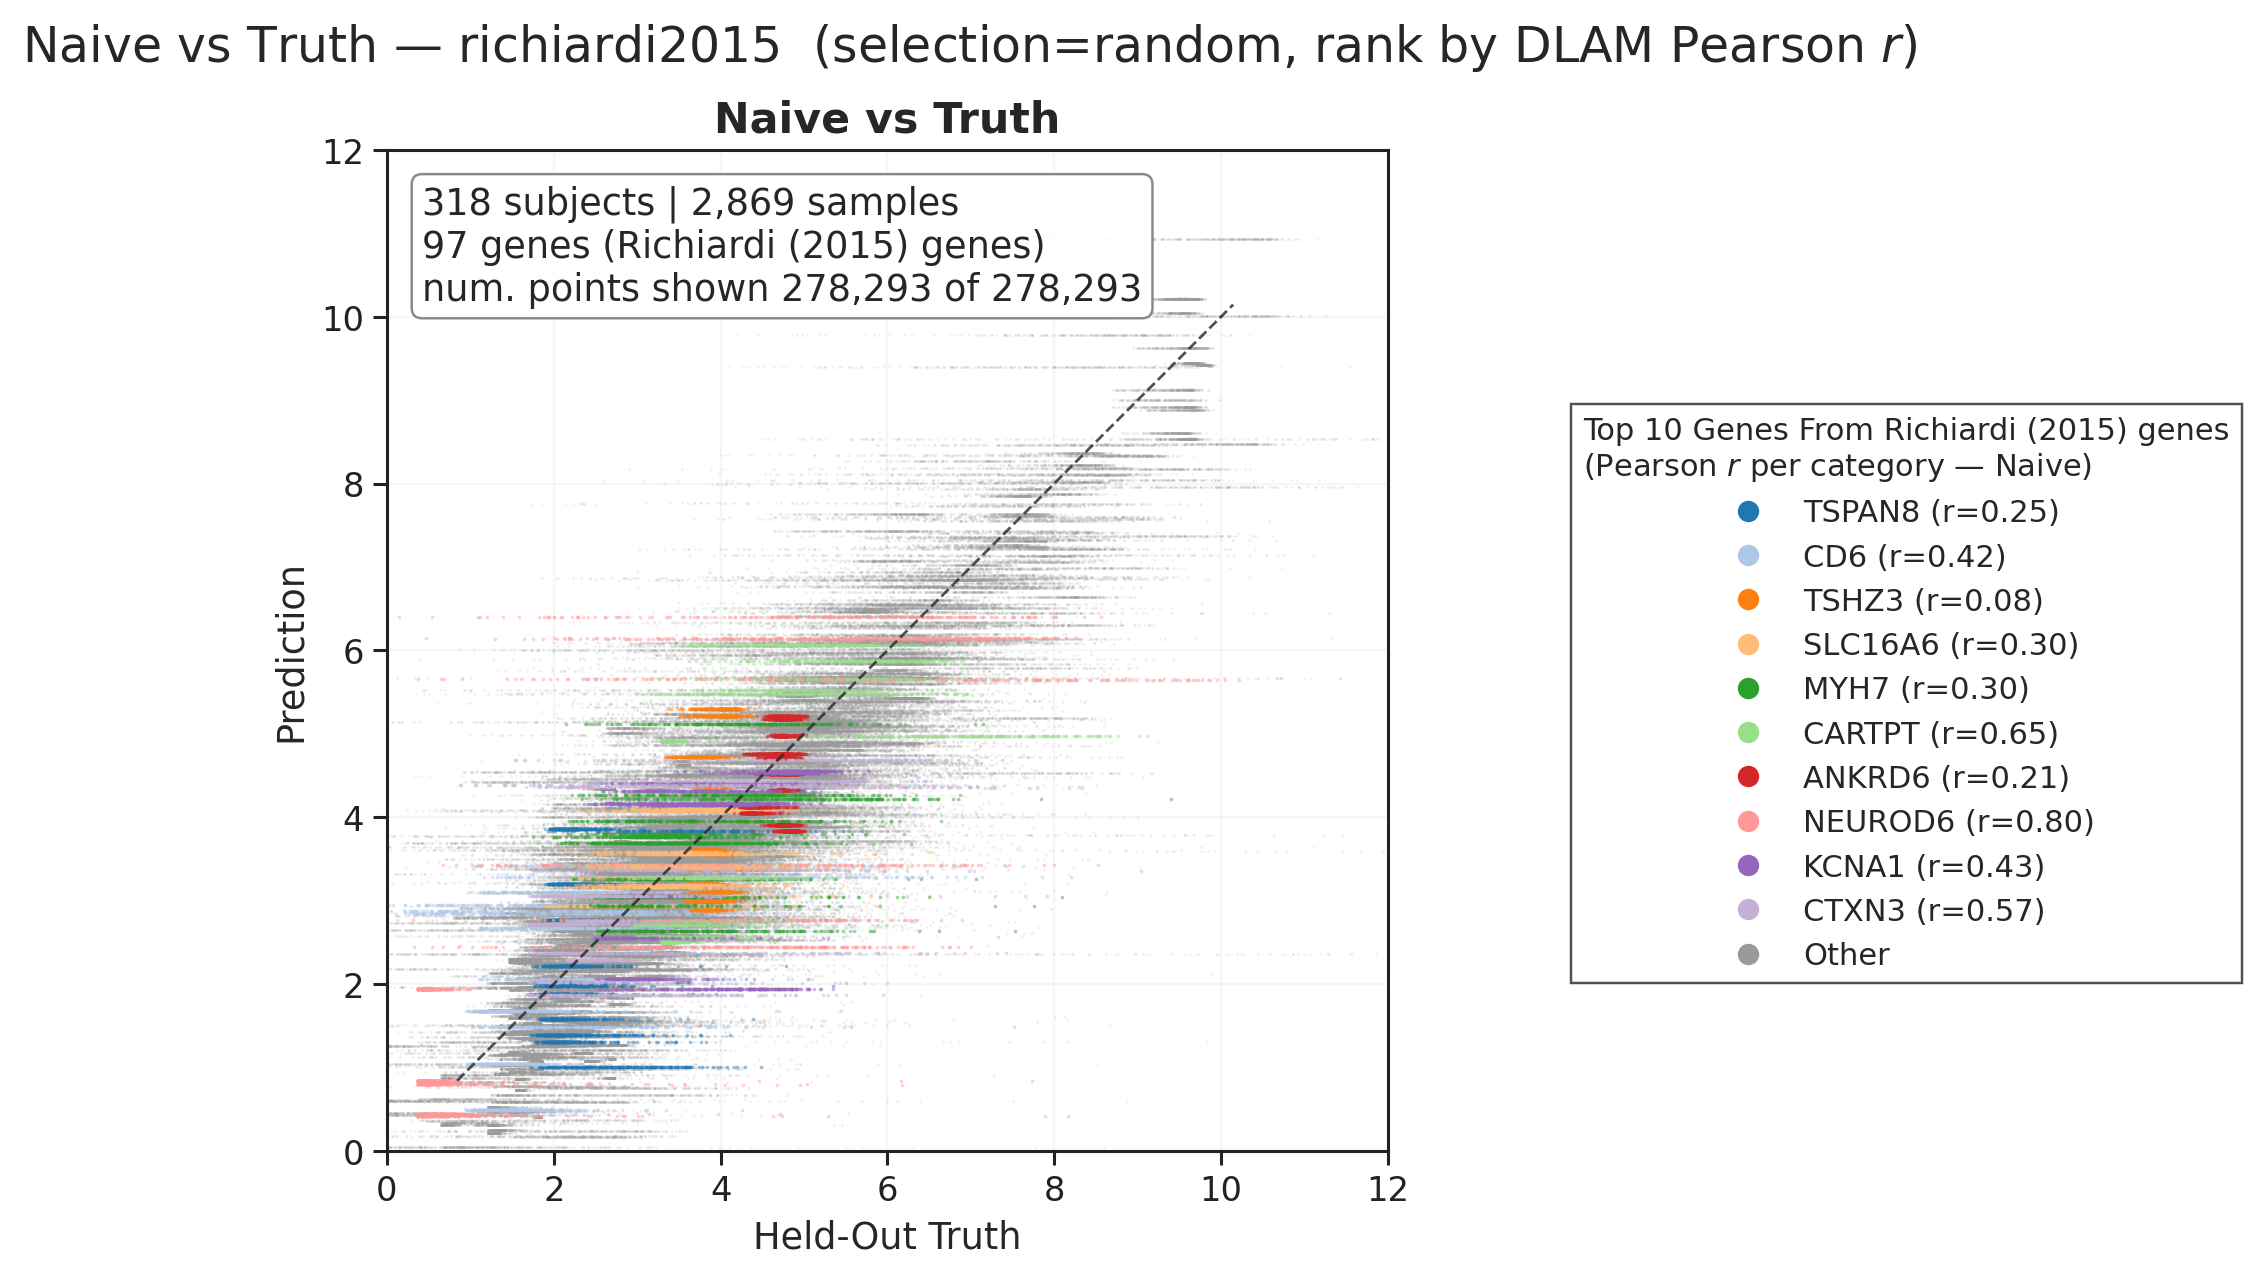

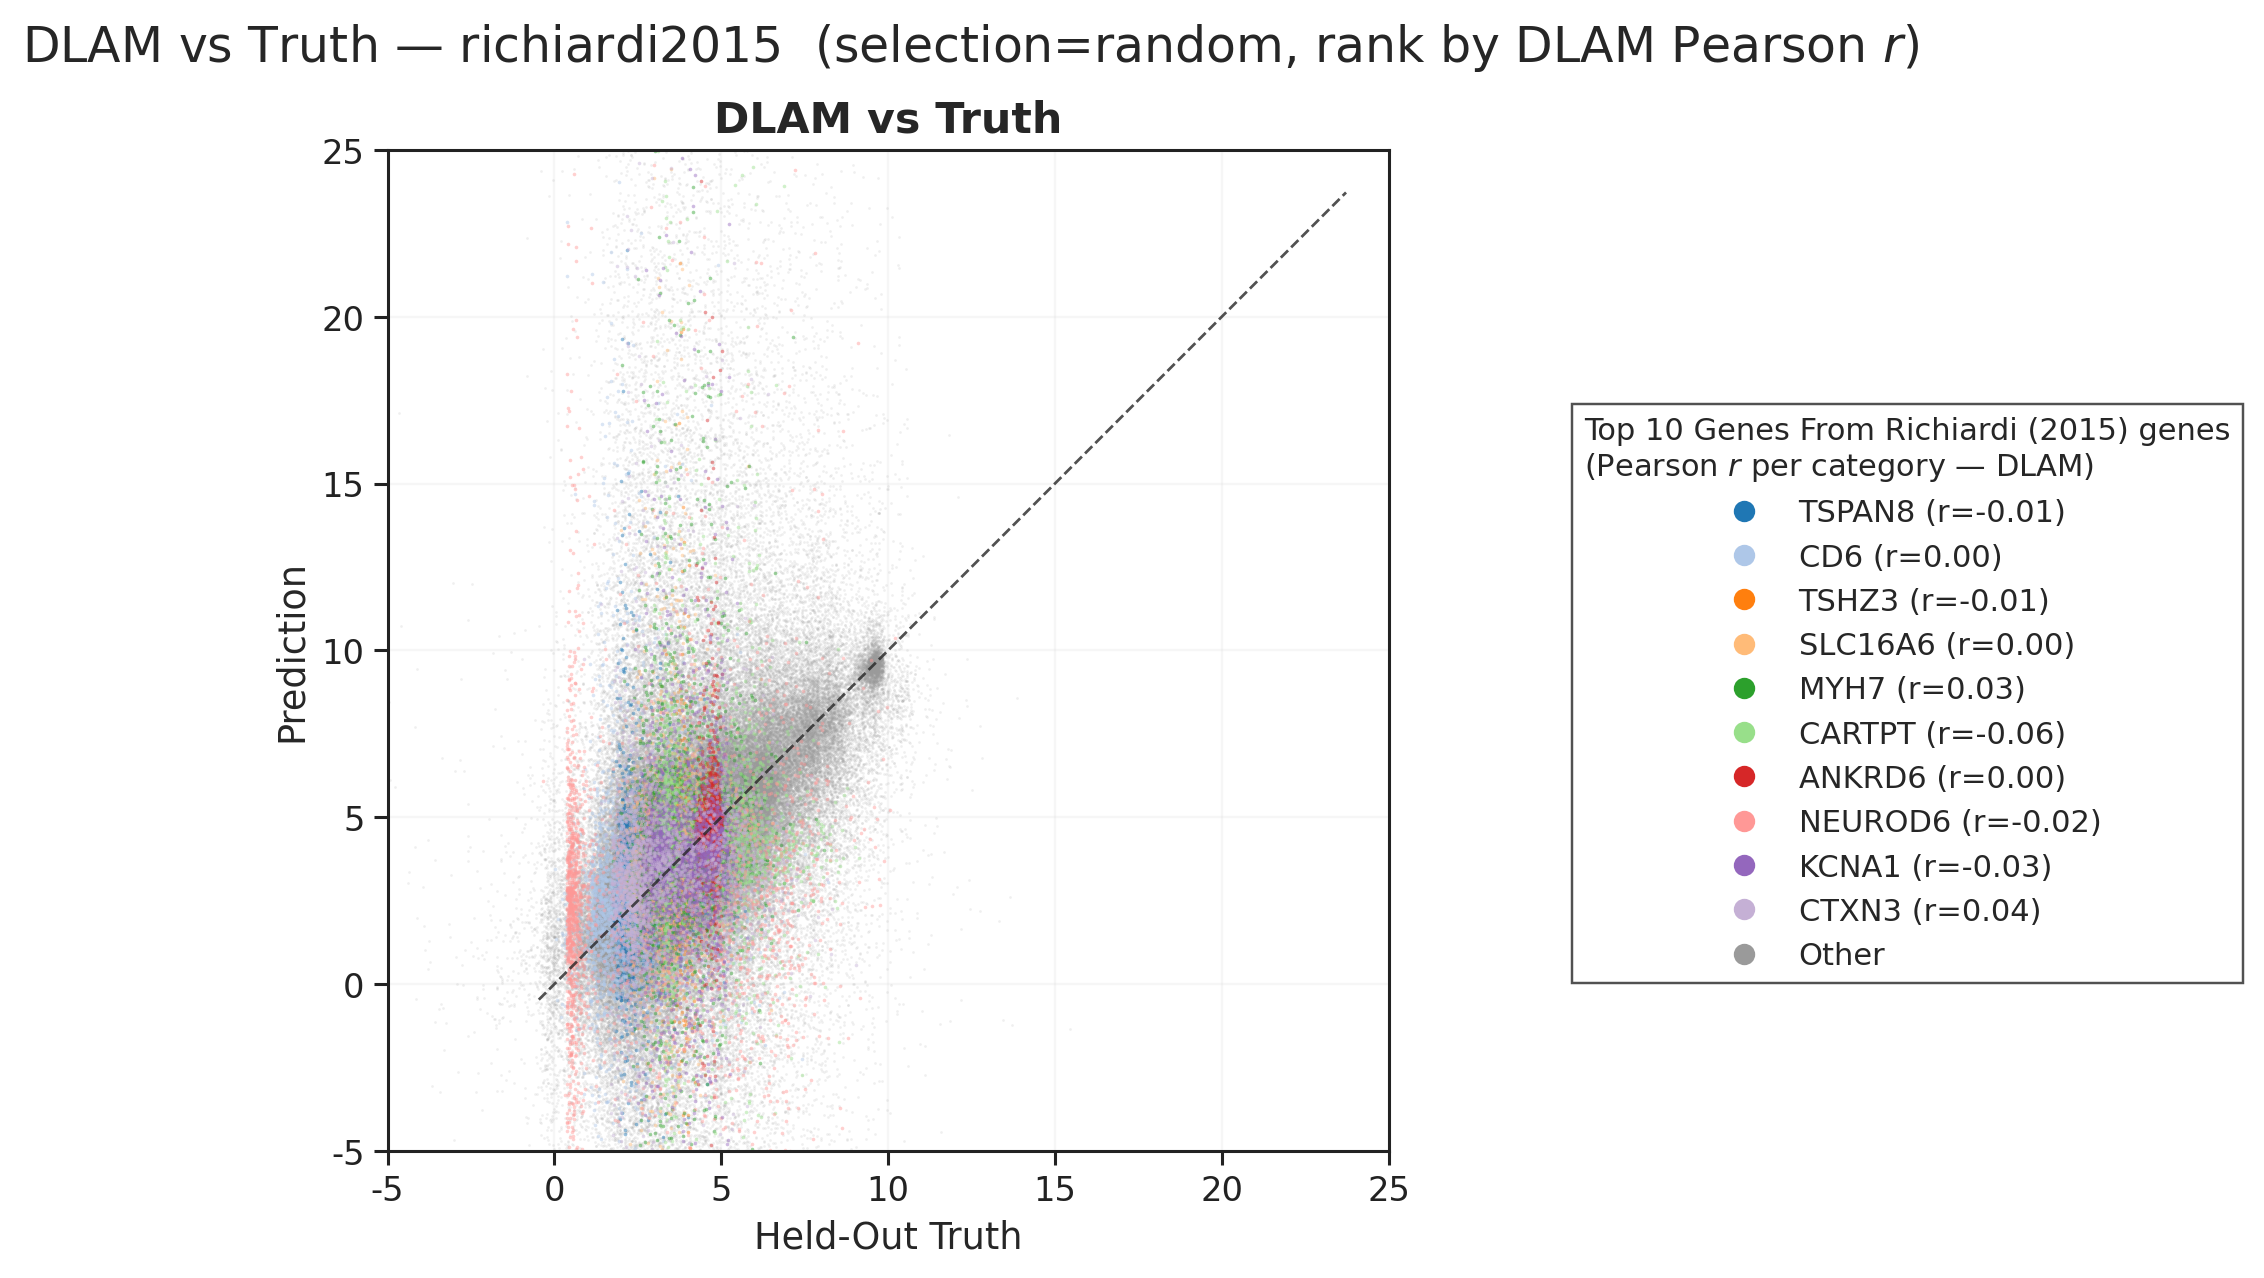

In [18]:
# One figure per model. The shared `sublist_rank_lookup` ensures all three panels
# color the same N genes for direct comparison.
for _model in MODELS:
    fig, axes = plot_global_prediction_scatter(
        build_panel_view(SUBLIST_GENE_LIST_PATH, models=[_model]),
        color_by='gene',
        top_n=SUBLIST_TOP_N,
        gene_selection=SUBLIST_SELECTION,
        gene_rank_lookup=sublist_rank_lookup,
        gene_rank_metric=SUBLIST_RANK_METRIC,
        highlight_genes=SUBLIST_HIGHLIGHT_GENES,
        figsize=SUBLIST_FIGSIZE,
        max_points_per_model=SCATTER_MAX_POINTS_PER_MODEL,
        annotate_metric_in_legend=SUBLIST_ANNOTATE_METRIC is not None,
        annotation_metric=SUBLIST_ANNOTATE_METRIC or 'pearson_r',
        random_seed=SUBLIST_RANDOM_SEED,
    )
    fig.suptitle(
        f"{model_label(_model)} vs Truth — {SUBLIST_GENE_LIST_PATH}  "
        f"(selection={SUBLIST_SELECTION}, rank by {model_label(SUBLIST_RANK_MODEL)} "
        f"{format_legend_label(SUBLIST_RANK_METRIC)})",
        fontsize=font_size('xxl'), y=0.97,
    )


## Section 4 — Interactive single-gene scatter

Pick a model and a gene from the configured panel; the scatter for **that gene only across all GTEx samples** renders below. Each point is one held-out subject-region observation; color = tissue.

Uses `ipywidgets` dropdowns (no `%matplotlib widget` / `ipympl` needed — every dropdown change just re-renders a regular inline figure). Re-render time is ~0.5–1 s per change.


In [19]:
# Section 4 config — interactive single-gene scatter
INTERACTIVE_GENE_LIST_PATH = SUBLIST_GENE_LIST_PATH   # reuse Section 3's panel by default
INTERACTIVE_COLOR_BY       = 'region'                 # tissue coloring on the per-gene scatter
INTERACTIVE_FIGSIZE        = (7.5, 6.5)
INTERACTIVE_DEFAULT_MODEL  = 'dlam'
INTERACTIVE_DEFAULT_GENE   = None                     # None = first alphabetically; or specify e.g. 'PVALB'


In [20]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt

# Resolve the gene panel from the configured list once for the dropdown options.
_interactive_view = build_panel_view(INTERACTIVE_GENE_LIST_PATH)
_gene_options = sorted(_interactive_view['genes'])
_default_gene = (
    INTERACTIVE_DEFAULT_GENE
    if INTERACTIVE_DEFAULT_GENE and INTERACTIVE_DEFAULT_GENE in _gene_options
    else _gene_options[0]
)

# 'all' renders one figure with all 3 model panels; a specific model renders one panel.
_model_options = ['all'] + list(MODELS)
_default_model = INTERACTIVE_DEFAULT_MODEL if INTERACTIVE_DEFAULT_MODEL in _model_options else 'all'

_model_dd = widgets.Dropdown(options=_model_options, value=_default_model, description='Model:')
_gene_dd  = widgets.Dropdown(options=_gene_options, value=_default_gene, description='Gene:')
_out      = widgets.Output()

def _render(*, model, gene):
    selected_models = list(MODELS) if model == 'all' else [model]
    _out.clear_output(wait=True)
    with _out:
        sub_view = build_panel_view(None, models=selected_models, genes=[gene])
        figsize = (
            (INTERACTIVE_FIGSIZE[0] * len(selected_models), INTERACTIVE_FIGSIZE[1])
            if len(selected_models) > 1 else INTERACTIVE_FIGSIZE
        )
        fig, axes = plot_global_prediction_scatter(
            sub_view,
            color_by=INTERACTIVE_COLOR_BY,
            figsize=figsize,
            annotate_metric_in_legend=True,
            annotation_metric='pearson_r',
        )
        title_models = ', '.join(model_label(m) for m in selected_models)
        fig.suptitle(
            f"{title_models} vs Truth — gene = {gene}  ({INTERACTIVE_GENE_LIST_PATH})",
            fontsize=font_size('xxl'), y=0.97,
        )
        plt.show()

def _on_change(_change):
    _render(model=_model_dd.value, gene=_gene_dd.value)

_model_dd.observe(_on_change, names='value')
_gene_dd.observe(_on_change, names='value')

display(widgets.HBox([_model_dd, _gene_dd]), _out)
_render(model=_model_dd.value, gene=_gene_dd.value)   # initial render


Output()

## Kendall-rank analysis

Within-subject spatial Kendall-τ analysis now lives in `notebooks/eval/results/eval_population_kendall.ipynb`.
